In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca

# import utils as ut
# import plot as pt
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *

/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [5]:
# activity_dict, double_predicted_activity_dict_NDNF_new, filtered_factors_dict, double_new_NDNF_activity_dict, double_new_NDNF_velocity_dict, double_residual_activity_dict_NDNF_new = load_data_double(name="NDNFanalC", double_track=False)
# activity_dict, filtered_factors_dict, double_new_NDNF_activity_dict_100, double_new_NDNF_velocity_dict_100, double_residual_activity_dict_NDNF_new_100 = load_data_double(name="NDNFanalC", double_track=True)

# GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(name="NDNFanalC", new_NDNF=True)
# GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True)

fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]



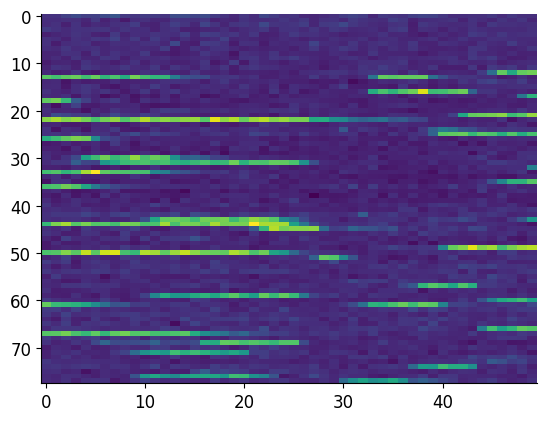

In [90]:
example_EC_cell = residual_activity_dict_EC['animal_1']['cell_5']
plt.imshow(example_EC_cell.T, aspect='auto')

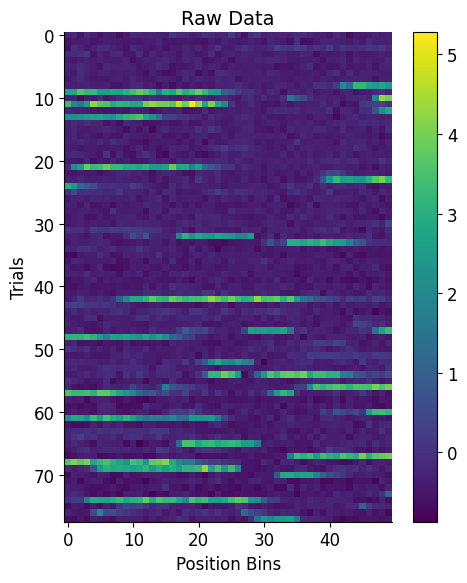

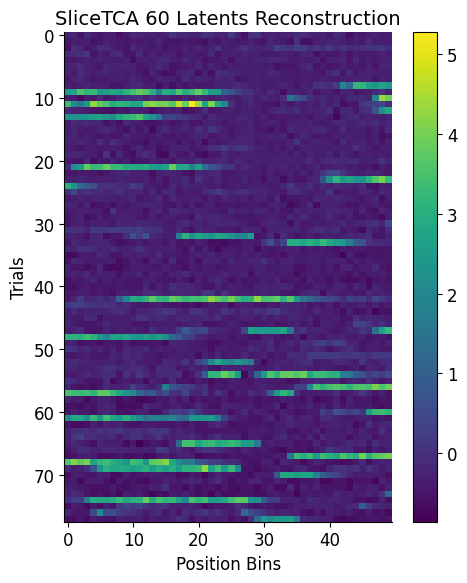

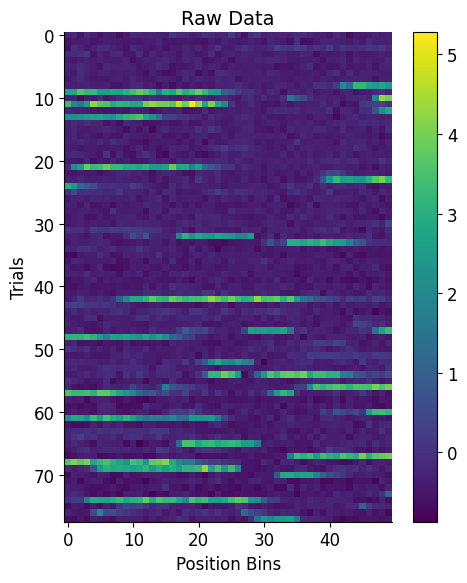

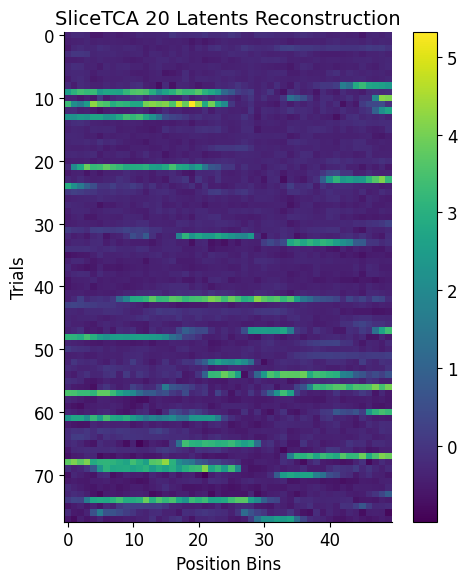

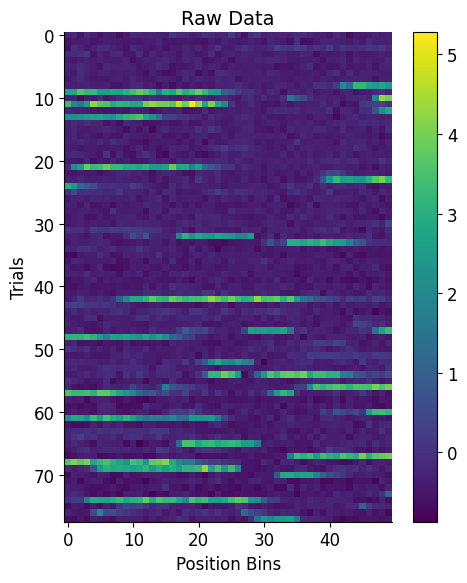

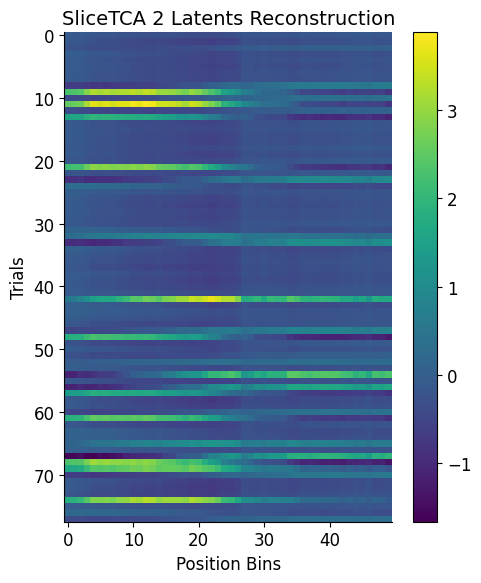

In [73]:

# To plot the reconstruction vs. original data:

def plot_model_vs_reco(example_EC_cell_tensor, model_60, x=60):
    reconstruction = model_60.construct().numpy(force=True).squeeze(axis=1)
    original = example_EC_cell_tensor.squeeze().cpu().numpy()

    fig, axs = plt.subplots(1,1, figsize=(5,6))

    im = axs.imshow(original, aspect='auto')
    axs.set_ylabel("Trials")
    axs.set_xlabel("Position Bins")
    axs.set_title("Raw Data", fontsize=14)
    fig.colorbar(im, ax=axs)
    plt.tight_layout()
    plt.show()

    fig, axs = plt.subplots(1,1, figsize=(5,6))

    axs.set_ylabel("Trials")
    axs.set_xlabel("Position Bins")
    axs.set_title(f"SliceTCA {x} Latents Reconstruction", fontsize=14)
    im = axs.imshow(reconstruction, aspect='auto')
    fig.colorbar(im, ax=axs)
    plt.tight_layout()
    plt.show()


plot_model_vs_reco(example_EC_cell_tensor, model_60, x=60)
plot_model_vs_reco(example_EC_cell_tensor, model_20, x=20)
plot_model_vs_reco(example_EC_cell_tensor, model_2, x=2)

    # plt.figure(figsize=(10,4))
# plt.subplot(1,2,1)
# plt.imshow(original, aspect='auto')
# plt.title("Original")
# plt.xlabel("Time bins")
# plt.ylabel("Trials")

# plt.subplot(1,2,2)
# plt.imshow(reconstruction, aspect='auto')
# plt.title("Reconstruction (60 comps)")
# plt.xlabel("Time bins")
# plt.ylabel("Trials")
# plt.tight_layout()
# plt.show()
# # ...existing code...

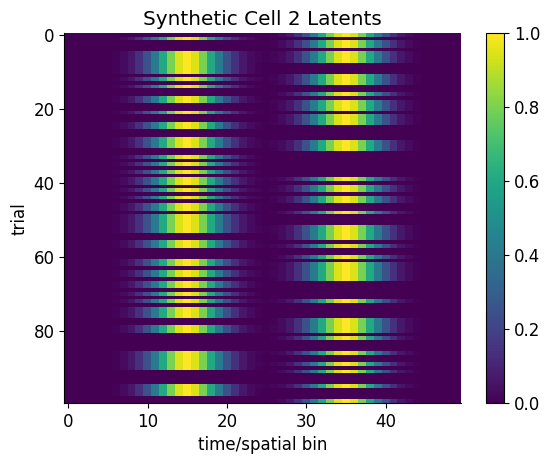

In [41]:
rng = np.random.default_rng(seed=42)

num_trials = 100
num_timebins = 50
ideal_cell = torch.zeros(num_trials, 1, num_timebins)

# Add gaussian place field
def place_field(x, mu, sigma):
    return torch.exp(-(x - mu)**2 / (2 * sigma**2))

field1 = place_field(torch.arange(num_timebins), mu=15, sigma=3)
field2 = place_field(torch.arange(num_timebins), mu=35, sigma=3)

x = np.linspace(-6, 6, num_trials)

for i in range(num_trials):
    express_field1 = rng.choice([0, 1])
    express_field2 = rng.choice([0, 1])
    ideal_cell[i] += express_field1*field1 + express_field2*field2


plt.imshow(ideal_cell[:, 0, :], interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xlabel('time/spatial bin')
plt.ylabel('trial')
plt.title("Synthetic Cell 2 Latents")
plt.show()

In [42]:
from sklearn.cluster import KMeans

The model converged. Loss: 2.0501622202573344e-05 :   7%|▋         | 1109/15000 [00:03<00:39, 347.51it/s]


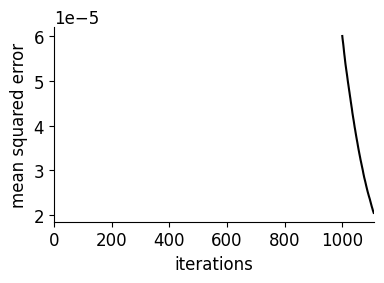

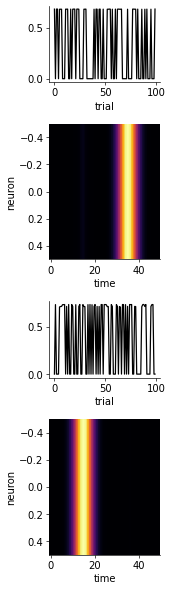

In [50]:
n_clusters=3

#### Run sliceTCA ####
device = ('cuda' if torch.cuda.is_available() else 'cpu')
neural_data_tensor = ideal_cell

components, model = slicetca.decompose(ideal_cell,
                                       number_components=(2,0,0), # (trials, neurons, time bins)
                                       positive=True,
                                       learning_rate=2*10**-3,
                                       min_std=10**-5,
                                       max_iter=15_000,
                                       seed=0)

plt.figure(figsize=(4,3), dpi=100)
plt.plot(np.arange(1000,len(model.losses)), model.losses[1000:], 'k')
plt.xlabel('iterations')
plt.ylabel('mean squared error')
plt.xlim(0,len(model.losses))
plt.tight_layout()

axes = slicetca.plot(model,
              variables=('trial', 'neuron', 'time'),
            #   ticks=(None, None, np.linspace(0,50,3)), # we only want to modify the time ticks
            #   tick_labels=(None, None, np.linspace(0,50,3)),
            #   sorting_indices=(None, neuron_sorting_peak_time, None),
              quantile=0.99)



In [152]:
import numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

def plot_sliceTCA_model(model):
    # --- data + kmeans ---
    X = torch.abs(model.vectors[0][0].detach().T).cpu().numpy()   # (trials, 2)
    k = 4
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    labels = km.fit_predict(X)
    centroids = km.cluster_centers_

    # --- fixed color map per cluster ---
    tab10 = mpl.colormaps['tab10'].colors
    cluster_colors = np.array([tab10[i % 10] for i in range(k)])  # color for cluster i
    point_colors = cluster_colors[labels]                          # color per trial

    # --- PCA for visualization ---
    pca = PCA(n_components=2)  # Reduce to 2 dimensions for scatter plot
    X_pca = pca.fit_transform(X)  # Fit and transform the data

    # ===== 1) latent space scatter =====
    plt.figure(figsize=(4, 4), dpi=140)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=point_colors, s=18, alpha=0.8,
                edgecolor='white', linewidth=0.5)
    plt.xlabel('PC 1'); plt.ylabel('PC 2'); plt.title('Trials in Latent Space')
    plt.tight_layout()
    plt.show()
    # centroid markers in the same cluster colors
    # plt.scatter(centroids[:,0], centroids[:,1], s=140,
    #             c=cluster_colors, edgecolor='k', linewidth=1.2)

    # legend that matches cluster colors
    handles = [Line2D([0],[0], marker='o', linestyle='', label=f'Cluster {c}',
                    markerfacecolor=cluster_colors[c], markeredgecolor='white',
                    markeredgewidth=0.5) for c in range(k)]
    plt.legend(handles=handles, frameon=False)

    plt.xlabel('Latent 1'); plt.ylabel('Latent 2'); plt.title('Trials in Latent Space')
    plt.tight_layout()

    # ===== 2) label per trial (same colors) =====
    plt.figure(figsize=(6,1.2), dpi=120)
    plt.scatter(np.arange(len(labels)), np.zeros_like(labels), c=point_colors, s=12)
    plt.yticks([]); plt.xlabel('Trial index'); plt.title('Cluster label per trial')
    plt.tight_layout()

    # ===== 3) latents sorted by cluster (overlay colored markers) =====
    order = np.argsort(labels)
    labels_sorted = labels[order]
    X_sorted = X[order]
    colors_sorted = cluster_colors[labels_sorted]

    plt.figure(figsize=(6,3), dpi=120)
    plt.plot(X_sorted[:,0], color='k', alpha=0.35, label='Latent 1 (line)')
    plt.plot(X_sorted[:,1], color='k', alpha=0.35, label='Latent 2 (line)')
    plt.scatter(np.arange(len(labels)), X_sorted[:,0], c=colors_sorted, s=10, label='Latent 1')
    plt.scatter(np.arange(len(labels)), X_sorted[:,1], c=colors_sorted, s=10, label='Latent 2', marker='s')

    # vertical dividers between clusters
    cuts = np.where(np.diff(labels_sorted)!=0)[0]
    for c in cuts: plt.axvline(c+0.5, linestyle='--', alpha=0.4)

    plt.legend(frameon=False); plt.title('Latents sorted by cluster'); plt.tight_layout()

    return labels, k



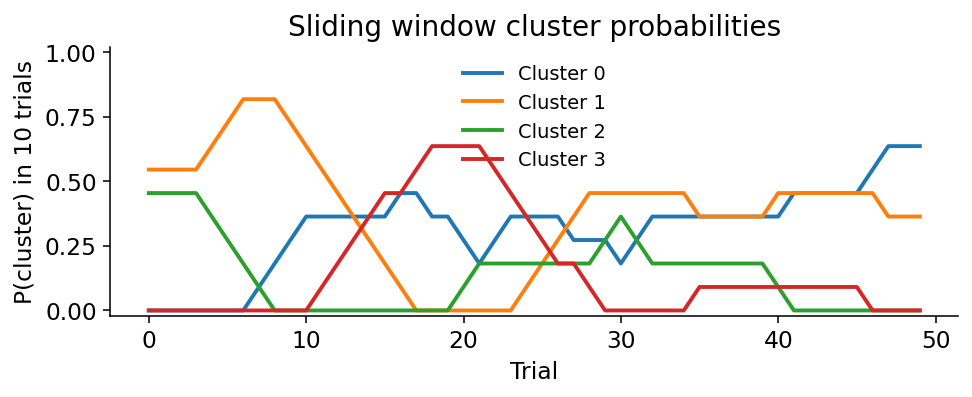

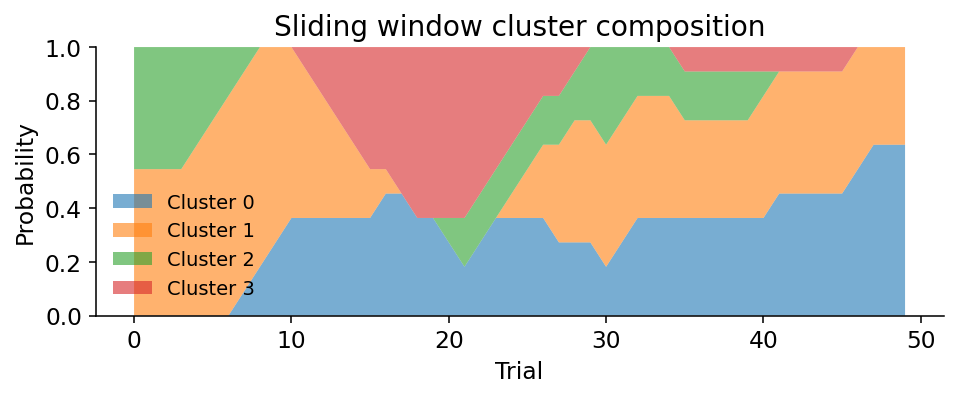

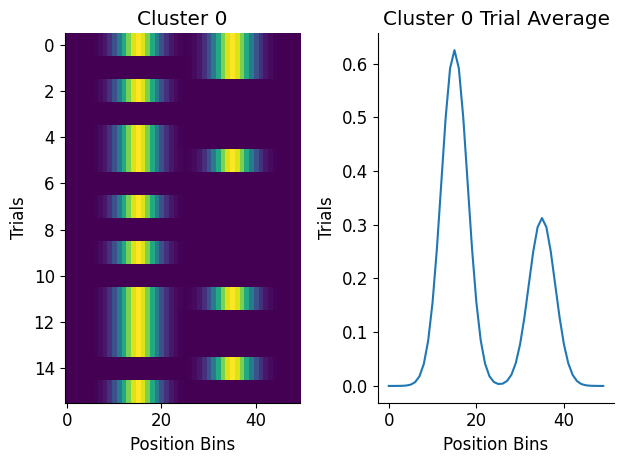

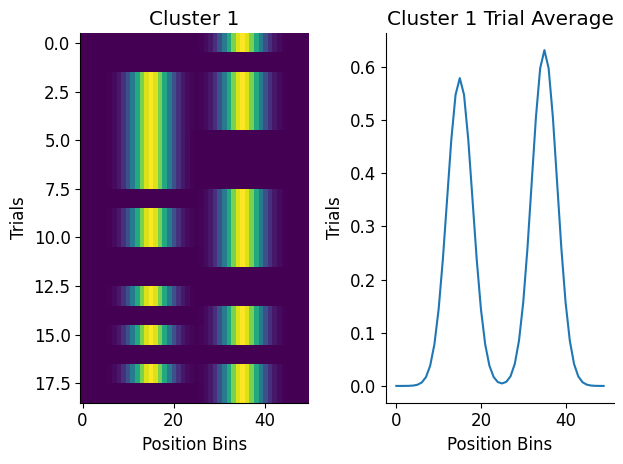

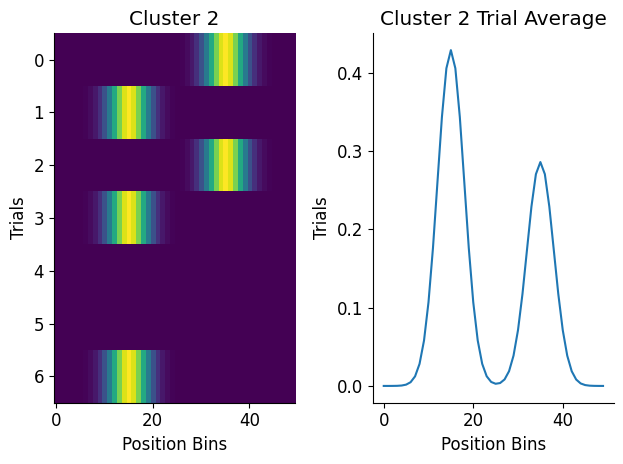

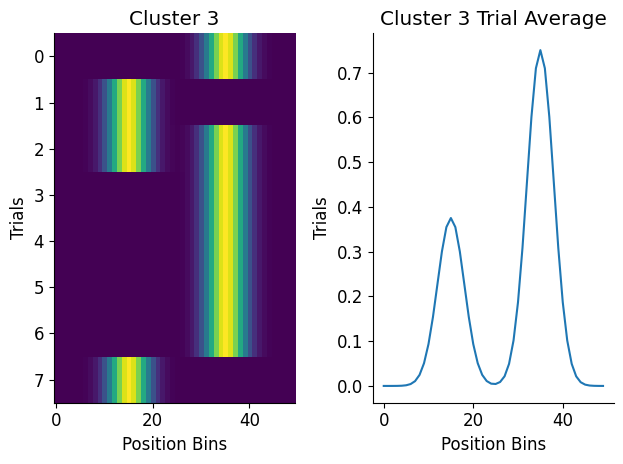

In [95]:
import numpy as np
import matplotlib.pyplot as plt

def sliding_cluster_probs(labels, k, window=15, pad_mode='reflect'):
    """
    Centered moving-average probability P(cluster=c) over trial index.
    Returns probs shape (n_trials, k). Rows sum to ~1.
    """
    labels = np.asarray(labels)
    n = labels.size
    if window < 1:
        raise ValueError("window must be >= 1")
    if window % 2 == 0:
        window += 1  # force odd for symmetric centering

    kernel = np.ones(window, dtype=float) / window
    probs = np.zeros((n, k), dtype=float)
    for c in range(k):
        ind = (labels == c).astype(float)
        ind_pad = np.pad(ind, (window//2, window//2), mode=pad_mode)
        probs[:, c] = np.convolve(ind_pad, kernel, mode='valid')
    return probs, window

def plot_sliceTCA_analyis(ideal_cell, labels, k):
    # --- compute probs ---
    probs, window = sliding_cluster_probs(labels, k, window=10)   # tweak window if you want
    x = np.arange(len(labels))

    # --- line plot per cluster (consistent colors) ---
    plt.figure(figsize=(7,3), dpi=140)
    for c in range(k):
        plt.plot(x, probs[:, c], label=f'Cluster {c}', color=cluster_colors[c], linewidth=2)
    plt.ylim(-0.02, 1.02)
    plt.xlabel('Trial'); plt.ylabel(f'P(cluster) in 10 trials')
    plt.title('Sliding window cluster probabilities')
    plt.legend(fontsize=10)
    plt.tight_layout()

    # --- optional: stacked area view ---
    plt.figure(figsize=(7,3), dpi=140)
    plt.stackplot(x, probs.T, labels=[f'Cluster {c}' for c in range(k)],
                colors=cluster_colors, alpha=0.6)
    plt.ylim(0, 1.0)
    plt.xlabel('Trial'); plt.ylabel('Probability')
    plt.title('Sliding window cluster composition')
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    labels_0 = np.where(labels==0)[0]
    labels_1 = np.where(labels==1)[0]
    labels_2 = np.where(labels==2)[0]
    labels_3 = np.where(labels==3)[0]

    data_0 = ideal_cell[labels_0, :, :].squeeze(axis=1)
    data_1 = ideal_cell[labels_1, :, :].squeeze(axis=1)
    data_2 = ideal_cell[labels_2, :, :].squeeze(axis=1)
    data_3 = ideal_cell[labels_3, :, :].squeeze(axis=1)

    fig, axs = plt.subplots(1,2)
    axs[0].imshow(data_0, aspect='auto')
    axs[0].set_title("Cluster 0")
    axs[0].set_xlabel("Position Bins")
    axs[0].set_ylabel("Trials")

    axs[1].plot(np.mean(data_0.cpu().numpy(), axis=0))
    axs[1].set_title("Cluster 0 Trial Average")
    axs[1].set_xlabel("Position Bins")
    axs[1].set_ylabel("Trials")
    plt.tight_layout()
    plt.show()

    fig, axs = plt.subplots(1,2)
    axs[0].imshow(data_1, aspect='auto')
    axs[0].set_title("Cluster 1")
    axs[0].set_xlabel("Position Bins")
    axs[0].set_ylabel("Trials")

    axs[1].plot(np.mean(data_1.cpu().numpy(), axis=0))
    axs[1].set_title("Cluster 1 Trial Average")
    axs[1].set_xlabel("Position Bins")
    axs[1].set_ylabel("Trials")
    plt.tight_layout()
    plt.show()

    fig, axs = plt.subplots(1,2)
    axs[0].imshow(data_2, aspect='auto')
    axs[0].set_title("Cluster 2")
    axs[0].set_xlabel("Position Bins")
    axs[0].set_ylabel("Trials")

    axs[1].plot(np.mean(data_2.cpu().numpy(), axis=0))
    axs[1].set_title("Cluster 2 Trial Average")
    axs[1].set_xlabel("Position Bins")
    axs[1].set_ylabel("Trials")
    plt.tight_layout()
    plt.show()

    fig, axs = plt.subplots(1,2)
    axs[0].imshow(data_3, aspect='auto')
    axs[0].set_title("Cluster 3")
    axs[0].set_xlabel("Position Bins")
    axs[0].set_ylabel("Trials")

    axs[1].plot(np.mean(data_3.cpu().numpy(), axis=0))
    axs[1].set_title("Cluster 3 Trial Average")
    axs[1].set_xlabel("Position Bins")
    axs[1].set_ylabel("Trials")
    plt.tight_layout()
    plt.show()
    
plot_sliceTCA_analyis(ideal_cell, labels, k)

In [69]:
example_EC_cell_tensor.shape

torch.Size([50, 1, 78])

In [70]:
ideal_cell.shape

torch.Size([100, 1, 50])

In [ ]:
################ using a real EC cell #######################

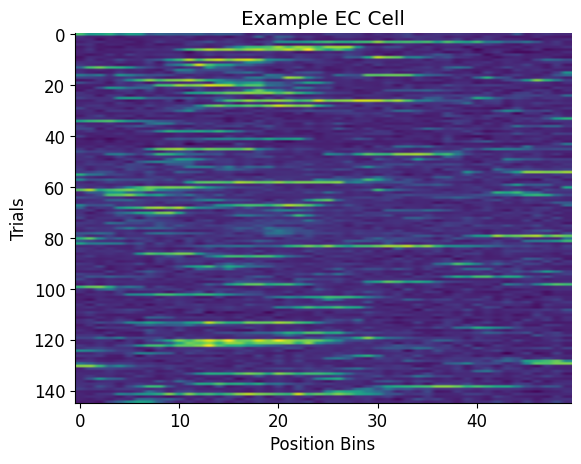

In [158]:
# example_EC_cell = residual_activity_dict_EC['animal_2']['cell_1']
example_EC_cell = residual_activity_dict_EC['animal_5']['cell_4']
plt.imshow(example_EC_cell.T, aspect='auto')
plt.title("Example EC Cell")
plt.ylabel("Trials")
plt.xlabel("Position Bins")
plt.show()


In [159]:

example_EC_cell_tensor = torch.from_numpy(example_EC_cell).unsqueeze(axis=1)
example_EC_cell_tensor = example_EC_cell_tensor.permute(2, 1, 0)
print(example_EC_cell_tensor.shape)  # should now be torch.Size([78, 1, 50])

# components_2, model_2 = slicetca.decompose(example_EC_cell_tensor,
#                                        number_components=(2,0,0), # (trials, neurons, time bins)
#                                        positive=False,
#                                        learning_rate=1*10**-3,
#                                        min_std=10**-5,
#                                        max_iter=15_000,
#                                        seed=0)


components_20, model_20 = slicetca.decompose(example_EC_cell_tensor,
                                       number_components=(20,0,0), # (trials, neurons, time bins)
                                       positive=False,
                                       learning_rate=1*10**-3,
                                       min_std=10**-5,
                                       max_iter=15_000,
                                       seed=0)

# components_60, model_60 = slicetca.decompose(example_EC_cell_tensor,
#                                        number_components=(60,0,0), # (trials, neurons, time bins)
#                                        positive=False,
#                                        learning_rate=1*10**-3,
#                                        min_std=10**-5,
#                                        max_iter=15_000,
#                                        seed=0)

torch.Size([145, 1, 50])


The model converged. Loss: 0.038635506545728934 :  31%|███       | 4591/15000 [00:47<01:46, 97.63it/s]


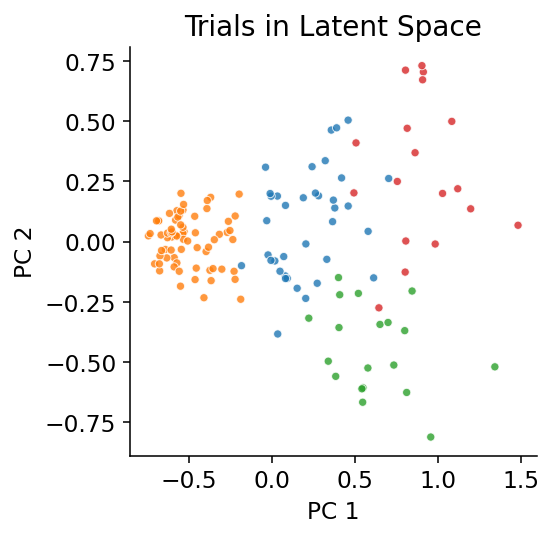

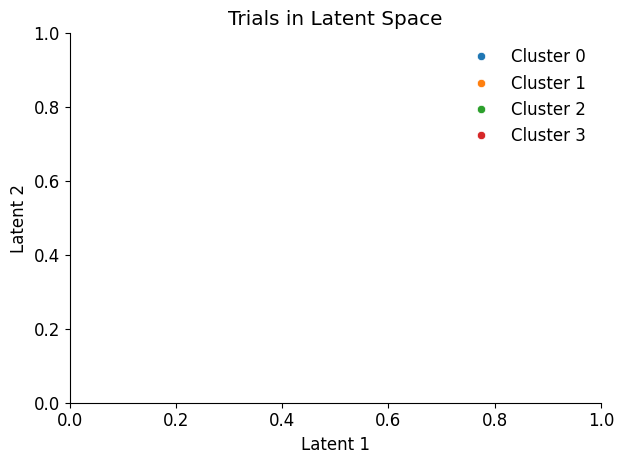

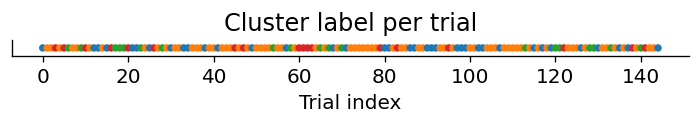

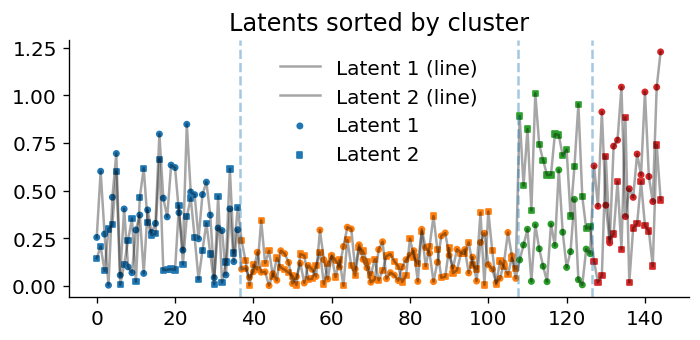

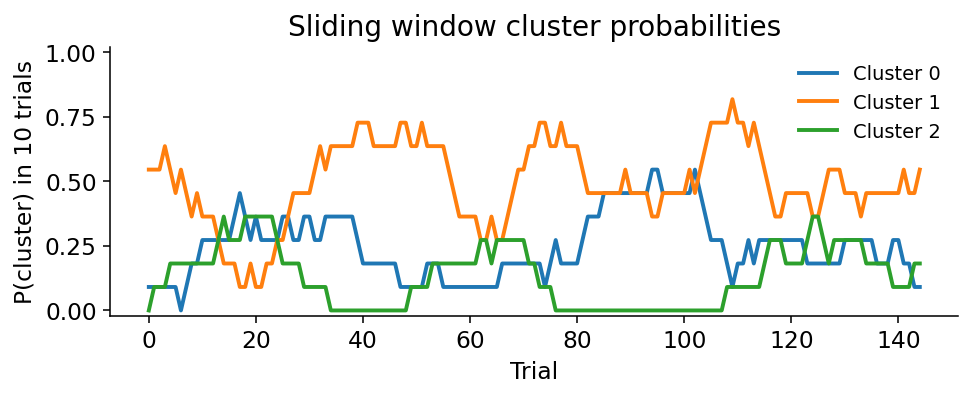

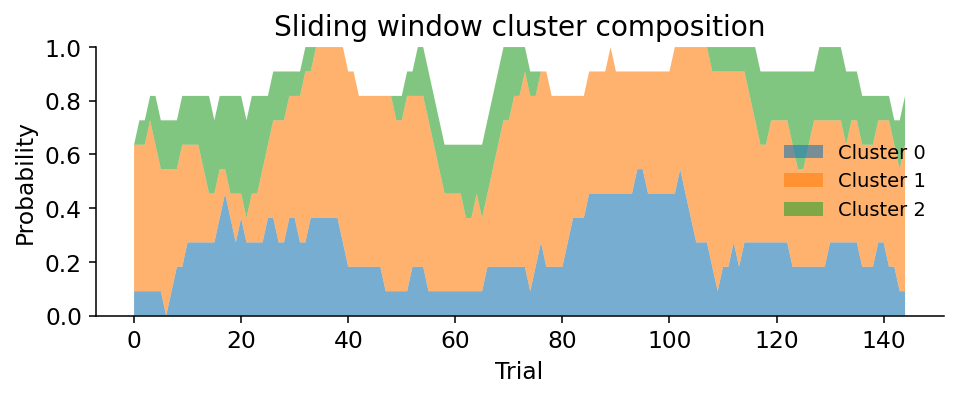

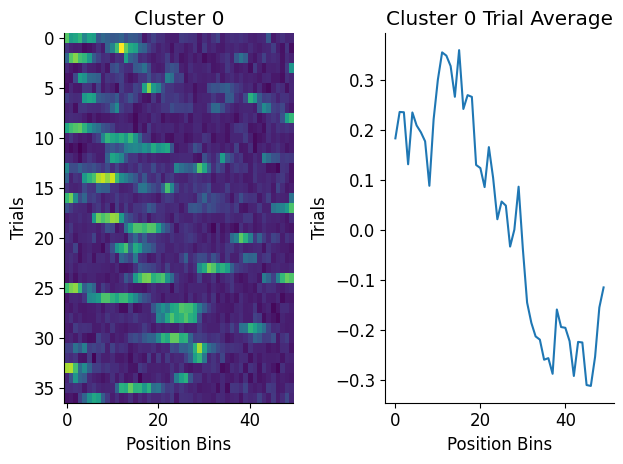

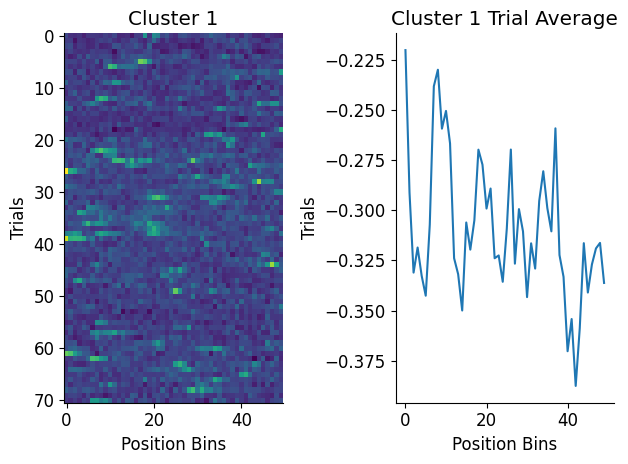

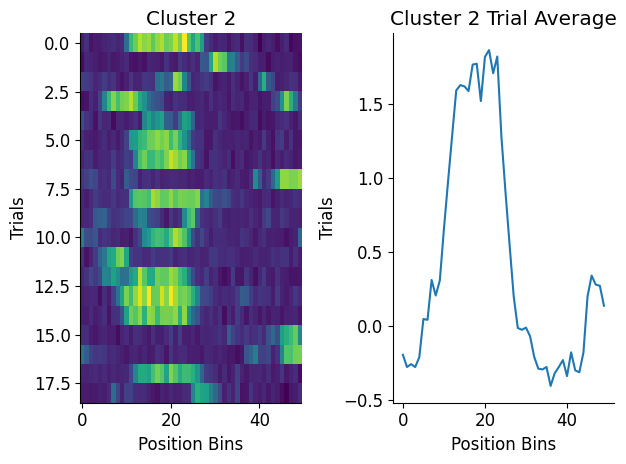

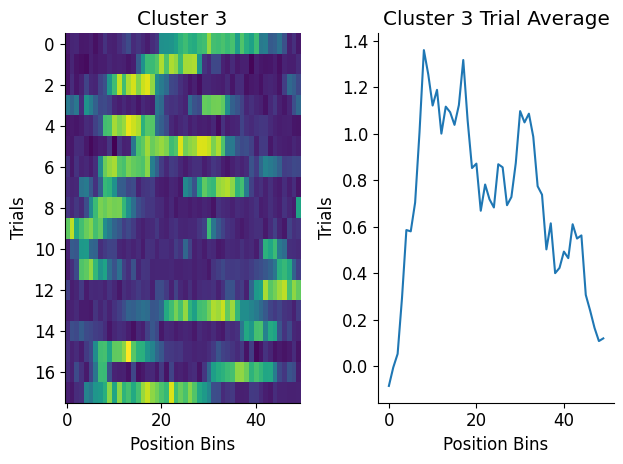

In [160]:
labels_20, k = plot_sliceTCA_model(model_20)
k=3
plot_sliceTCA_analyis(example_EC_cell_tensor, labels_20, k)

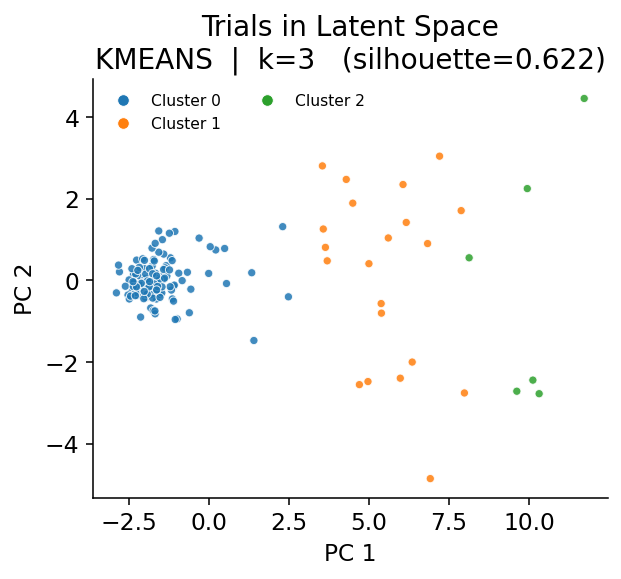

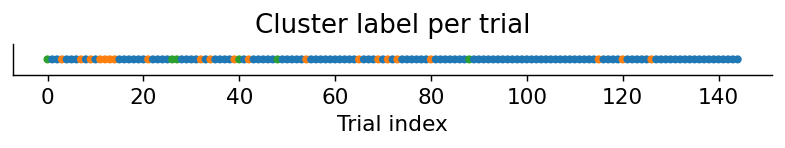

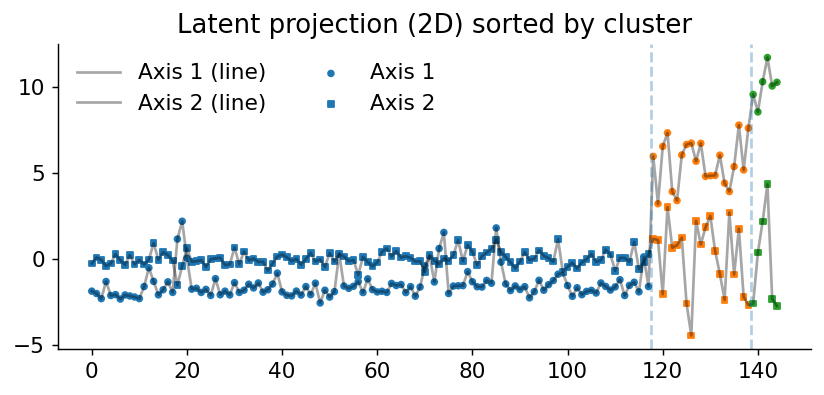

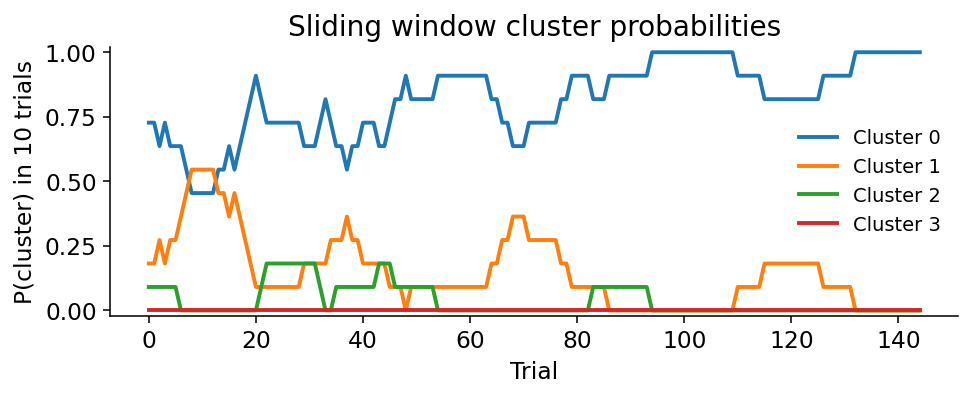

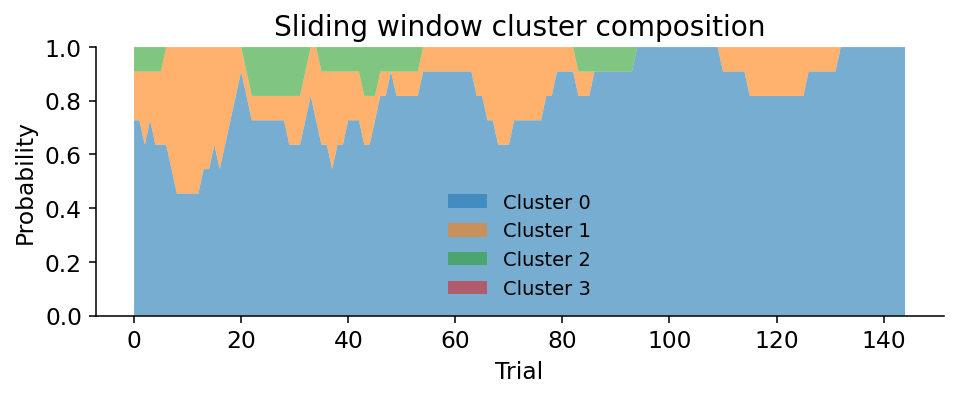

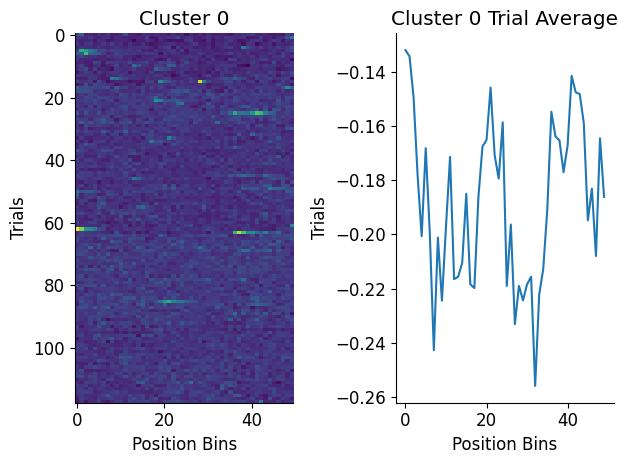

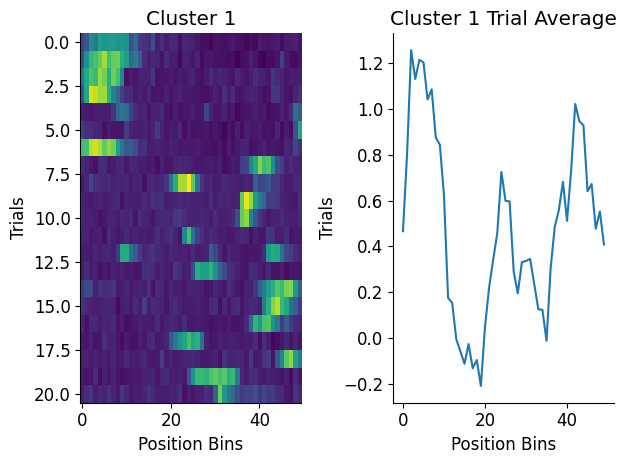

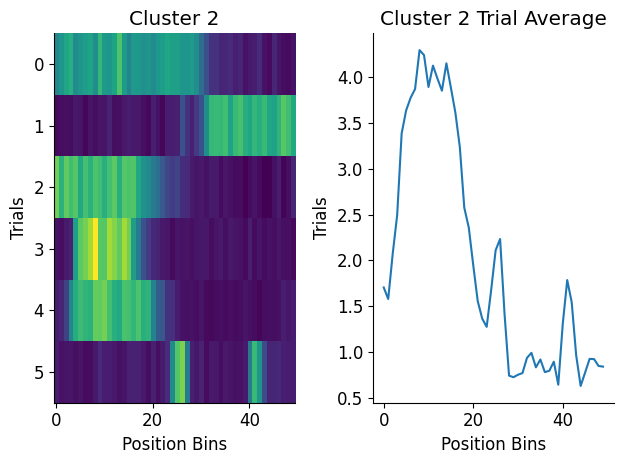

/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_14739/2984165250.py:100: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axs[0].imshow(data_3, aspect='auto')
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


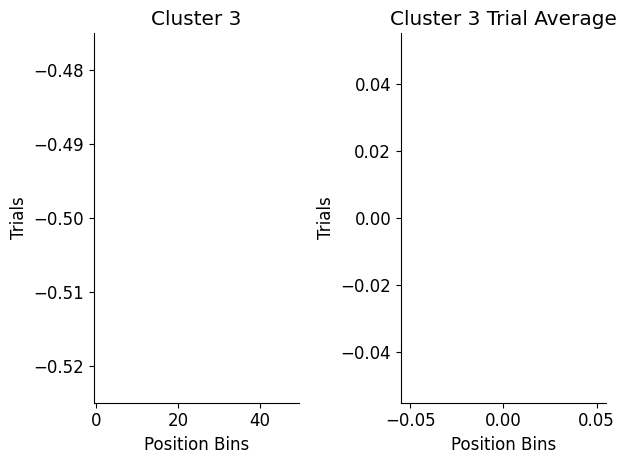

In [140]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import torch

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ---------- helpers ----------

def _standardize(X, zscore=True):
    if not zscore:
        return X
    sc = StandardScaler()
    return sc.fit_transform(X)

def _pick_k_kmeans(X, k_range=range(2,  nine := 10)):  # k=2..9 by default
    best_k, best_score, best_labels, best_model = None, -1, None, None
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=20, random_state=0)
        labels = km.fit_predict(X)
        # guard against degenerate labels
        if len(np.unique(labels)) < 2:
            continue
        score = silhouette_score(X, labels)
        if score > best_score:
            best_k, best_score, best_labels, best_model = k, score, labels, km
    return best_labels, best_k, best_model, best_score

def _pick_k_gmm(X, k_range=range(2,  nine := 10)):
    best_k, best_bic, best_labels, best_model = None, np.inf, None, None
    for k in k_range:
        gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=5, random_state=0)
        gmm.fit(X)
        bic = gmm.bic(X)
        if bic < best_bic:
            best_bic, best_k, best_model = bic, k, gmm
    labels = best_model.predict(X)
    return labels, best_k, best_model, best_bic

def _cluster(X_full, method='kmeans', zscore=True, k=None, eps=0.5, min_samples=5):
    X = _standardize(X_full, zscore=zscore)

    if method == 'kmeans':
        if k is None:
            labels, k, model, score = _pick_k_kmeans(X)
        else:
            model = KMeans(n_clusters=k, n_init=20, random_state=0)
            labels = model.fit_predict(X)
            score = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else np.nan
        info = dict(method='kmeans', k=k, quality='silhouette', metric_value=float(score))
        return labels, info

    elif method == 'gmm':
        if k is None:
            labels, k, model, bic = _pick_k_gmm(X)
        else:
            model = GaussianMixture(n_components=k, covariance_type='full', n_init=5, random_state=0)
            labels = model.fit_predict(X)
            bic = model.bic(X)
        info = dict(method='gmm', k=k, quality='bic', metric_value=float(bic))
        return labels, info

    elif method == 'dbscan':
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
        labels = db.labels_  # -1 = noise
        # compute a silhouette score if we have >=2 clusters, else NaN
        uniq = np.unique(labels[labels >= 0])
        score = silhouette_score(X[labels >= 0], labels[labels >= 0]) if len(uniq) >= 2 else np.nan
        info = dict(method='dbscan', k=int(len(uniq)), quality='silhouette_nonnoise', metric_value=float(score))
        return labels, info

    else:
        raise ValueError("method must be one of {'kmeans','gmm','dbscan'}")

# ---------- main plotter ----------

def plot_sliceTCA_model(model, use_pca=True, method='kmeans', zscore=True,
                        k=None, dbscan_eps=0.5, dbscan_min_samples=5, title_prefix='Trials in Latent Space'):
    """
    Clusters on FULL latent space (no PCA). PCA only for 2D plotting.
      method: 'kmeans' | 'gmm' | 'dbscan'
      k:      if None, auto-selects (silhouette for kmeans, BIC for GMM). Ignored for DBSCAN.
    """
    # trials x latents
    X_full = torch.abs(model.vectors[0][0].detach().T).cpu().numpy()

    # ---- cluster on full space ----
    labels, info = _cluster(
        X_full, method=method, zscore=zscore, k=k,
        eps=dbscan_eps, min_samples=dbscan_min_samples
    )
    # map noise to a separate color index at the end (for DBSCAN)
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels[unique_labels >= 0])

    # ---- 2D coords for viz (PCA only if helpful) ----
    if use_pca and X_full.shape[1] > 2:
        pca = PCA(n_components=2, random_state=0)
        X = pca.fit_transform(_standardize(X_full, zscore=zscore))
        xlbl, ylbl = 'PC 1', 'PC 2'
    else:
        X = X_full[:, :2] if X_full.shape[1] > 1 else np.c_[X_full[:, 0], np.zeros(len(X_full))]
        xlbl, ylbl = 'Latent 1', 'Latent 2'

    # ---- colors ----
    tab10 = mpl.colormaps['tab10'].colors
    # assign color per cluster id (keep -1 as gray if present)
    def color_for(lbl):
        return (0.6, 0.6, 0.6) if lbl == -1 else tab10[int(lbl) % 10]
    point_colors = np.array([color_for(l) for l in labels])

    # ---- jitter to reduce overlap ----
    rng = np.random.default_rng(0)
    sx, sy = X[:,0].ptp() or 1.0, X[:,1].ptp() or 1.0
    Xj = X + rng.normal(scale=[0.02*sx, 0.02*sy], size=X.shape)

    # ===== 1) 2D scatter =====
    plt.figure(figsize=(4.6, 4.3), dpi=140)
    plt.scatter(Xj[:,0], Xj[:,1], c=point_colors, s=18, alpha=0.85,
                edgecolor='white', linewidth=0.5)
    handles = []
    for lbl in sorted(unique_labels):
        name = 'Noise' if lbl == -1 else f'Cluster {int(lbl)}'
        handles.append(
            Line2D([0],[0], marker='o', linestyle='', label=name,
                   markerfacecolor=color_for(lbl), markeredgecolor='white', markeredgewidth=0.5)
        )
    plt.legend(handles=handles, fontsize=8, frameon=False, ncol=2)
    subtitle = f"{info['method'].upper()}  |  k={info['k']}" if info['method']!='dbscan' else f"DBSCAN  |  clusters={n_clusters}"
    metric_str = f"{info['quality']}={info['metric_value']:.3f}" if np.isfinite(info['metric_value']) else f"{info['quality']}=N/A"
    plt.title(f'{title_prefix}\n{subtitle}   ({metric_str})')
    plt.xlabel(xlbl); plt.ylabel(ylbl)
    plt.tight_layout()

    # ===== 2) label per trial =====
    plt.figure(figsize=(6.2, 1.3), dpi=130)
    plt.scatter(np.arange(len(labels)), np.zeros_like(labels), c=point_colors, s=12)
    plt.yticks([]); plt.xlabel('Trial index'); plt.title('Cluster label per trial'); plt.tight_layout()

    # ===== 3) latents sorted by cluster =====
    order = np.argsort(labels)
    labels_sorted = labels[order]
    X_sorted = X[order]
    colors_sorted = point_colors[order]

    plt.figure(figsize=(6.5, 3.2), dpi=130)
    plt.plot(X_sorted[:,0], color='k', alpha=0.35, label='Axis 1 (line)')
    plt.plot(X_sorted[:,1], color='k', alpha=0.35, label='Axis 2 (line)')
    plt.scatter(np.arange(len(labels)), X_sorted[:,0], c=colors_sorted, s=10, label='Axis 1')
    plt.scatter(np.arange(len(labels)), X_sorted[:,1], c=colors_sorted, s=10, label='Axis 2', marker='s')

    cuts = np.where(np.diff(labels_sorted)!=0)[0]
    for c in cuts: plt.axvline(c+0.5, linestyle='--', alpha=0.35)

    plt.legend(frameon=False, ncol=2)
    plt.title('Latent projection (2D) sorted by cluster')
    plt.tight_layout()

    return labels, info

# ---------- example ----------
# Cluster with auto-k KMeans, visualize with PCA, z-score latents:
labels_20, info_20 = plot_sliceTCA_model(model_20, use_pca=True, method='kmeans', zscore=True, k=3)
plot_sliceTCA_analyis(example_EC_cell_tensor, labels_20, k)
# Or: GMM auto-k by BIC
# labels_20, info_20 = plot_sliceTCA_model(model_20, use_pca=True, method='gmm', zscore=True)

# Or: DBSCAN (tune eps/min_samples for your trial count/density)
# labels_20, info_20 = plot_sliceTCA_model(model_20, use_pca=True, method='dbscan', zscore=True, dbscan_eps=0.6, dbscan_min_samples=6)

# Then pass the labels forward:
# plot_sliceTCA_analyis(example_EC_cell_tensor, labels_20, info_20.get('k', None))


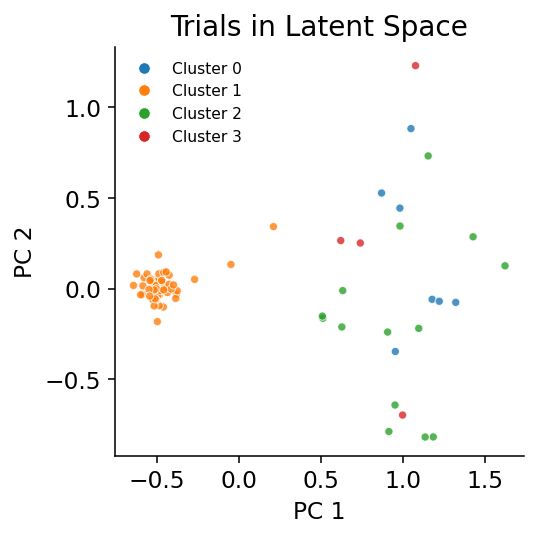

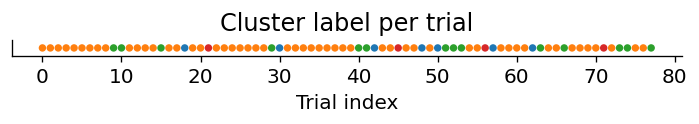

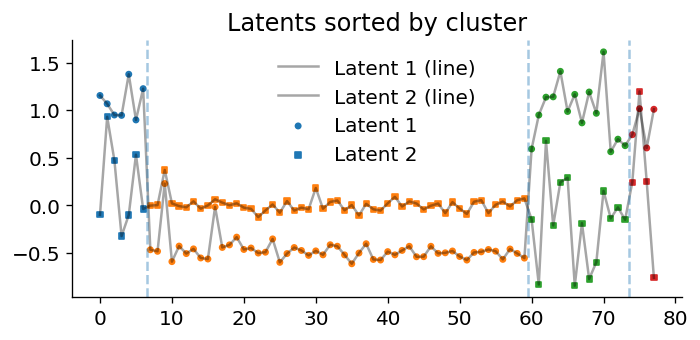

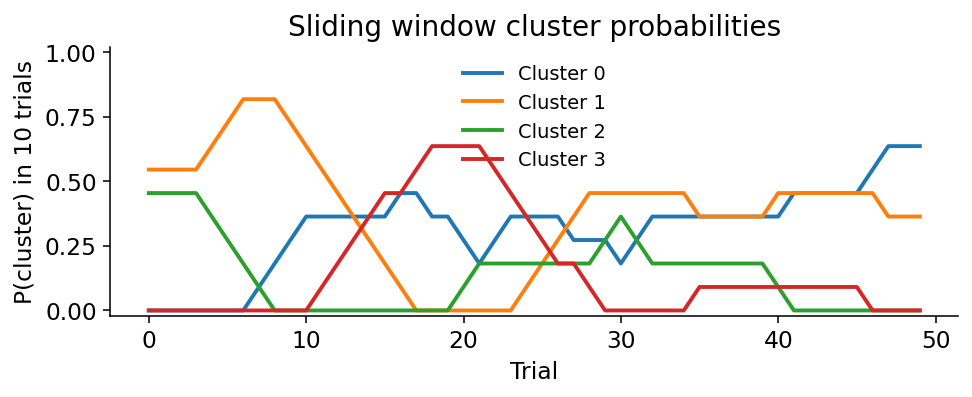

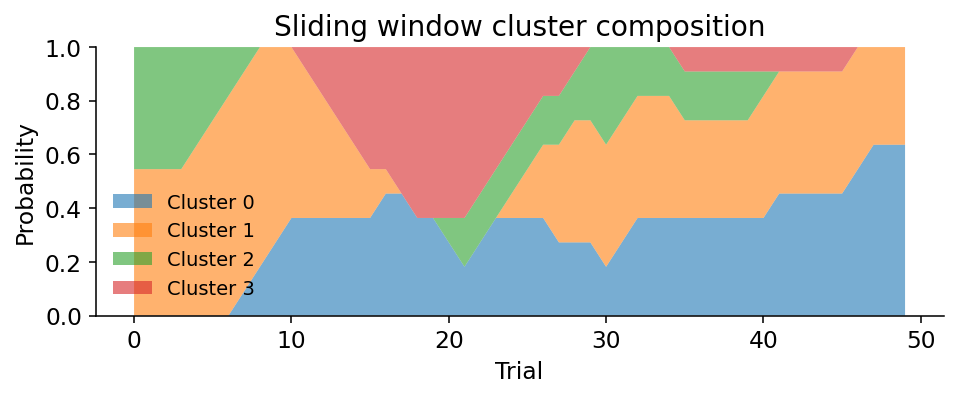

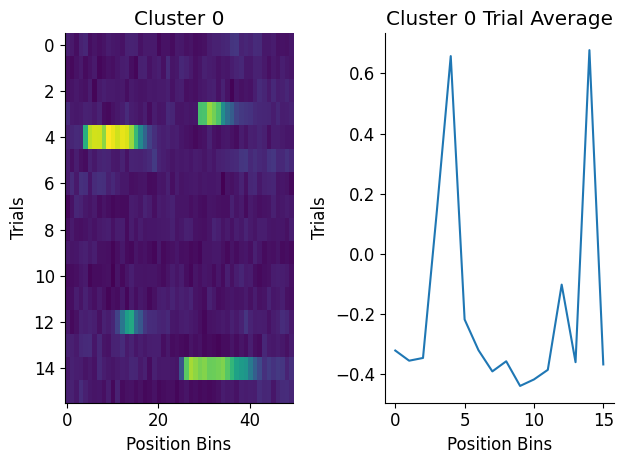

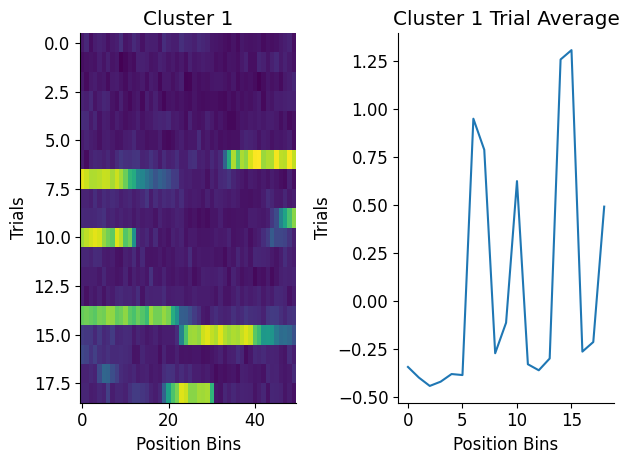

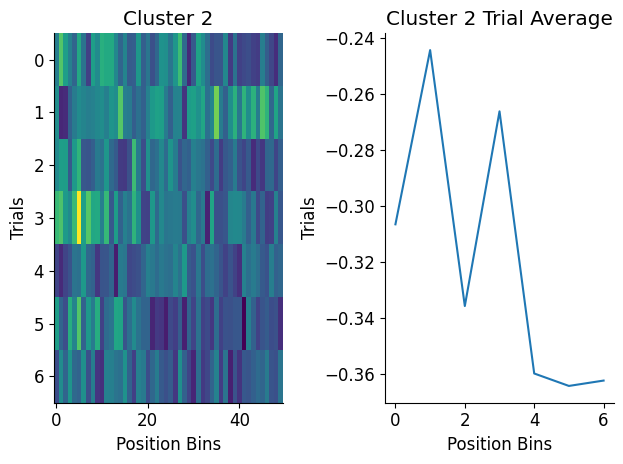

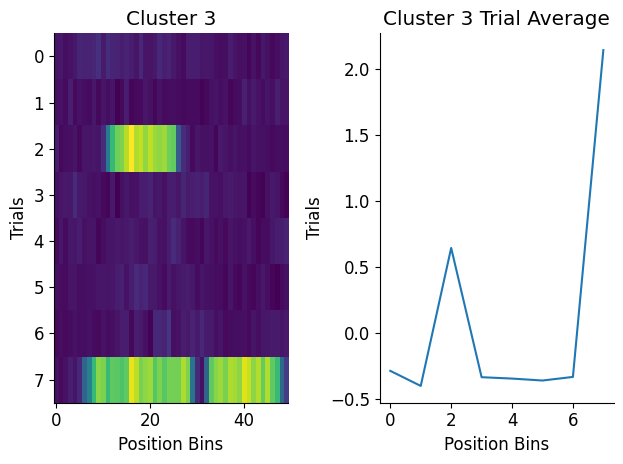

In [87]:
# Example usage:
labels_20, k_20 = plot_sliceTCA_model(model_20, use_pca=True)
plot_sliceTCA_analyis(example_EC_cell_tensor, labels, k)

In [162]:
pwd

'/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date'

In [165]:
################ clusters must be of size 3+

mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell'
testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir ='/Users/michaelfinch/CA1-interneuron-GLM/datasets/testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell'
testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir ='/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell'
real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell = get_model_data_per_cell(mse_dir)

fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue = {20: {}}
for idx, animal in enumerate(real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20]):
    if 17<idx<31:
        fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue[20][animal-18] = real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20][animal]
        

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

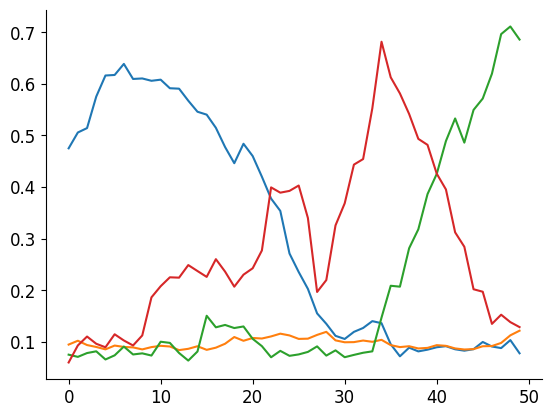

In [177]:
cell=0
animal=0
data = testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["cluster_trial_mean_dict"]["clusters_chosen_4"]

plt.plot(data[0])
plt.plot(data[1])
plt.plot(data[2])
plt.plot(data[3])
plt.show()

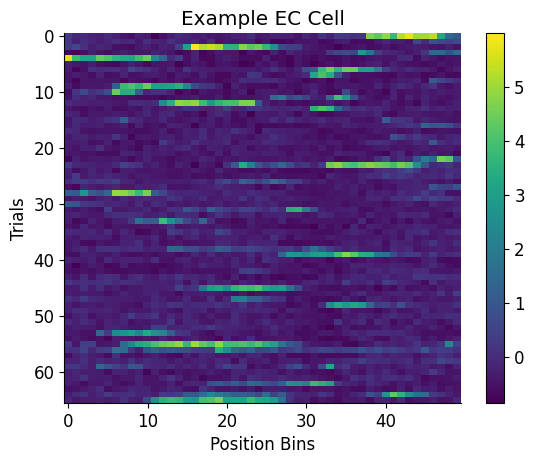

In [250]:
d = residual_activity_dict_EC['animal_2']['cell_4']
plt.imshow(d.T, aspect='auto')
plt.ylabel("Trials")
plt.xlabel("Position Bins")
plt.title("Example EC Cell")
plt.colorbar()
plt.show()

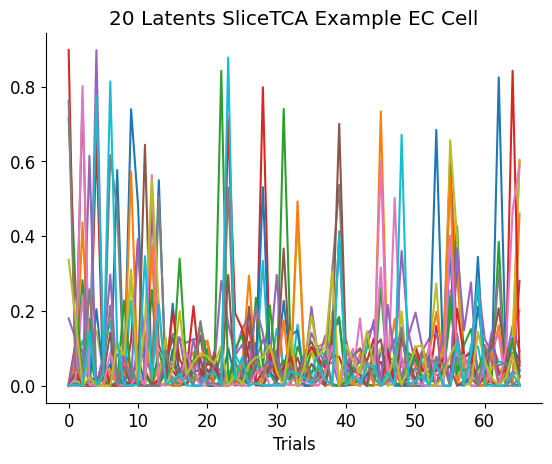

In [256]:
model_ex_cell = testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][0]
latents = torch.abs(model_ex_cell.vectors[0][0].detach().T).cpu().numpy()
for i in range(latents.shape[1]):
    plt.plot(latents[:,i])
plt.xlabel("Trials")
plt.title("20 Latents SliceTCA Example EC Cell")
plt.show()


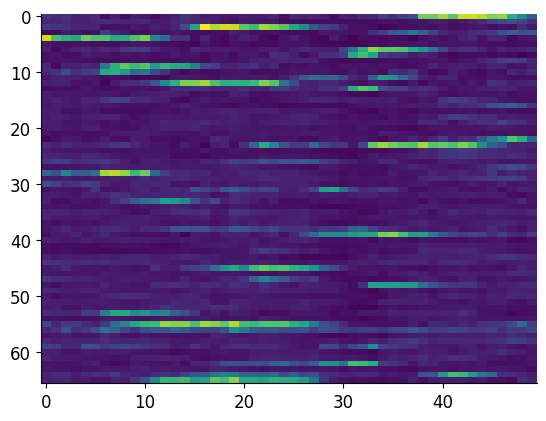

In [ ]:
animal=1
cell=3
data = testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]['TCA_reconstructions_dict']['clusters_chosen_4']

plt.imshow(data, aspect='auto')
plt.ylabel()
plt.show()

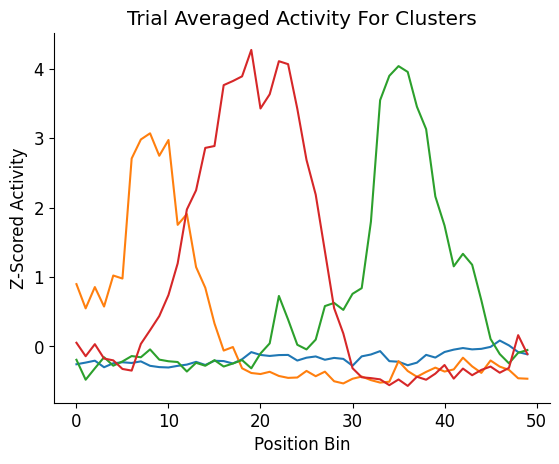

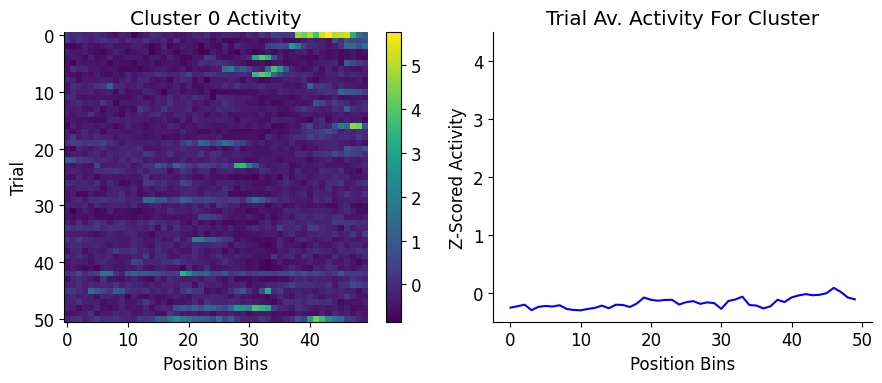

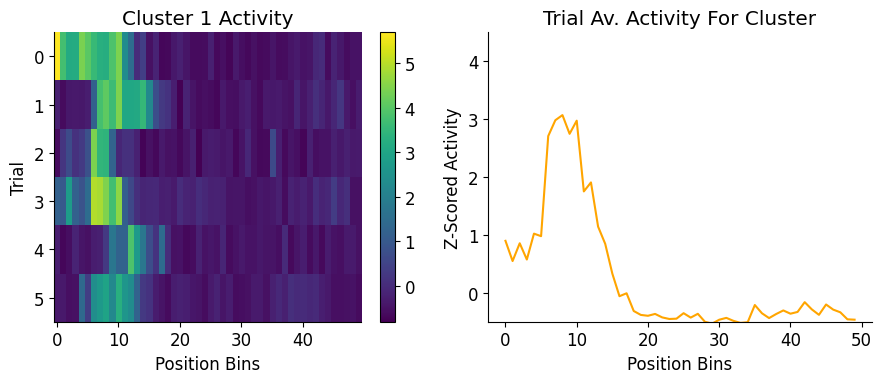

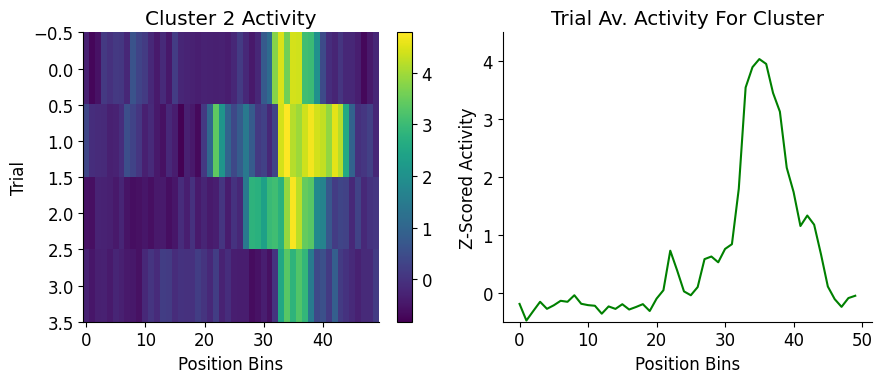

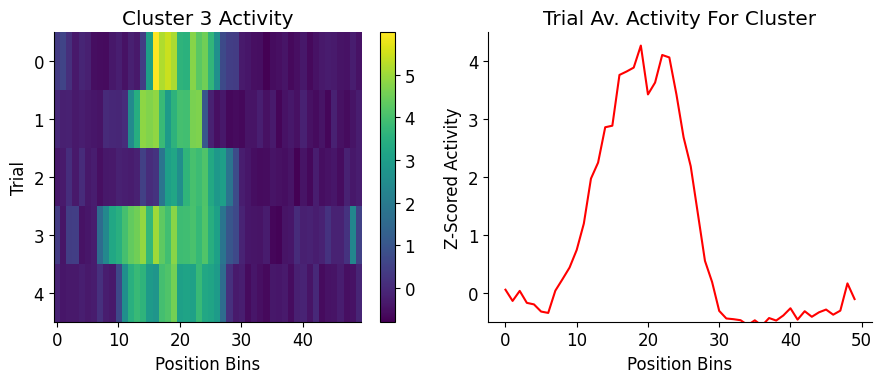

In [270]:
#animal0cell5
#animal1cell3

animal=1
cell=3
labels = testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["indices_for_cluster_number"]["clusters_chosen_4"]

activity = residual_activity_dict_EC[f'animal_{animal+1}'][f'cell_{cell+1}']

group_0_act = activity[:, labels[0]]
group_1_act = activity[:, labels[1]]
group_2_act = activity[:, labels[2]]
group_3_act = activity[:, labels[3]]

plt.plot(np.mean(group_0_act,axis=1), label='Cluster 0')
plt.plot(np.mean(group_1_act,axis=1), label='Cluster 1')
plt.plot(np.mean(group_2_act,axis=1), label='Cluster 2')
plt.plot(np.mean(group_3_act,axis=1), label='Cluster 3')
plt.ylabel("Z-Scored Activity")
plt.xlabel("Position Bin")
plt.title("Trial Averaged Activity For Clusters")
plt.show()


fig, axs = plt.subplots(1,2, figsize=(9,4))
im=axs[0].imshow(group_0_act.T, aspect='auto')
fig.colorbar(im, ax=axs[0])
axs[1].plot(np.mean(group_0_act,axis=1), color='blue')
axs[0].set_ylabel("Trial")
axs[1].set_ylabel("Z-Scored Activity")
axs[0].set_xlabel("Position Bins")
axs[1].set_xlabel("Position Bins")
axs[0].set_title("Cluster 0 Activity")
axs[1].set_title("Trial Av. Activity For Cluster")
axs[1].set_ylim(-0.5, 4.5)
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1,2, figsize=(9,4))
im=axs[0].imshow(group_1_act.T, aspect='auto')
fig.colorbar(im, ax=axs[0])
axs[1].plot(np.mean(group_1_act,axis=1), color='orange')
axs[0].set_ylabel("Trial")
axs[1].set_ylabel("Z-Scored Activity")
axs[0].set_xlabel("Position Bins")
axs[1].set_xlabel("Position Bins")
axs[0].set_title("Cluster 1 Activity")
axs[1].set_title("Trial Av. Activity For Cluster")
axs[1].set_ylim(-0.5, 4.5)
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1,2, figsize=(9,4))
im=axs[0].imshow(group_2_act.T, aspect='auto')
fig.colorbar(im, ax=axs[0])
axs[1].plot(np.mean(group_2_act,axis=1), color='green')
axs[0].set_ylabel("Trial")
axs[1].set_ylabel("Z-Scored Activity")
axs[0].set_xlabel("Position Bins")
axs[1].set_xlabel("Position Bins")
axs[0].set_title("Cluster 2 Activity")
axs[1].set_title("Trial Av. Activity For Cluster")
axs[1].set_ylim(-0.5, 4.5)
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1,2, figsize=(9,4))
im=axs[0].imshow(group_3_act.T, aspect='auto')
fig.colorbar(im, ax=axs[0])
axs[1].plot(np.mean(group_3_act,axis=1), color='red')
axs[0].set_ylabel("Trial")
axs[1].set_ylabel("Z-Scored Activity")
axs[0].set_xlabel("Position Bins")
axs[1].set_xlabel("Position Bins")
axs[0].set_title("Cluster 3 Activity")
axs[1].set_title("Trial Av. Activity For Cluster")
axs[1].set_ylim(-0.5, 4.5)
plt.tight_layout()
plt.show()




/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_14739/478000404.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = plt.cm.get_cmap('tab10')  # Use tab10 colormap


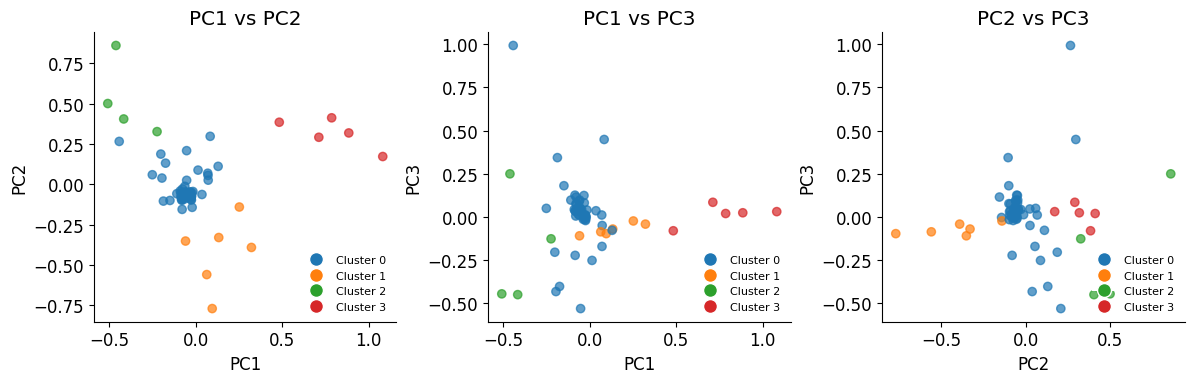

In [267]:
import itertools
import matplotlib.pyplot as plt

# Extract PCA data
x_pca = testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["x_pca_dict"]['clusters_chosen_4']

# Flatten the labels dictionary into a trial-to-cluster mapping
trial_to_cluster = {}
for cluster, trials in labels.items():
    for trial in trials:
        trial_to_cluster[trial] = cluster

# Create a list of cluster labels for each trial in order
trial_labels = [trial_to_cluster[trial] for trial in range(len(x_pca))]

# Map each trial's label to a color from tab10
tab10 = plt.cm.get_cmap('tab10')  # Use tab10 colormap
label_colors = [tab10(int(cluster) % 10) for cluster in trial_labels]

# Generate all pairs of principal components for plotting
pc_pairs = list(itertools.combinations(range(x_pca.shape[1]), 2))

# Create subplots for each pair of principal components
fig, axs = plt.subplots(1, len(pc_pairs), figsize=(12, 4))

for i, (pc1, pc2) in enumerate(pc_pairs):
    scatter = axs[i].scatter(x_pca[:, pc1], x_pca[:, pc2], c=label_colors, alpha=0.7)
    axs[i].set_xlabel(f'PC{pc1+1}')
    axs[i].set_ylabel(f'PC{pc2+1}')
    axs[i].set_title(f'PC{pc1+1} vs PC{pc2+1}')
    axs[i].legend(handles=handles, loc='lower right', fontsize=8)  # Add legend to each subplot


# Add a legend for the clusters
unique_clusters = sorted(set(trial_labels))  # Get unique cluster labels
handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {cluster}',
                      markerfacecolor=tab10(int(cluster) % 10), markersize=10) for cluster in unique_clusters]
# fig.legend(handles=handles, loc='upper center', ncol=len(unique_clusters), bbox_to_anchor=(0.5, 1.1))

plt.tight_layout()
plt.show()